## Generate some mock data

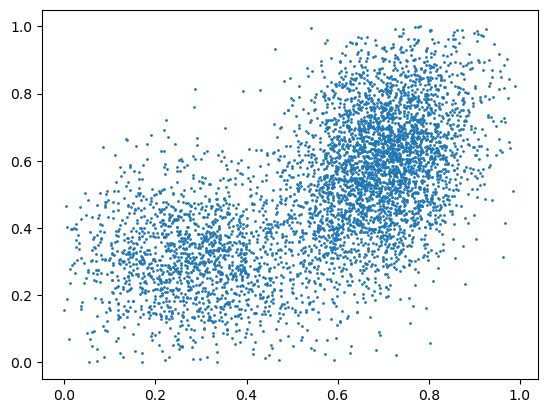

In [1]:
from matplotlib import pyplot as plt
from generate_mock_data import sample_poisson_process, mixture_density

components = [
    {"mean": [0.3, 0.3], "cov": [[0.02, 0.0], [0.0, 0.02]], "weight": 1.0},
    {"mean": [0.7, 0.6], "cov": [[0.01, 0.005], [0.005, 0.03]], "weight": 2.0},
]
points = sample_poisson_process(components, total_intensity=5000, bounds=[(0, 1), (0, 1)], seed=1)
plt.scatter(points[:,0], points[:,1], s=1);

## Adaptive kd-tree triangulation

#### This is sort of meant as an initialization of the triangulation

In [2]:
import sys
sys.path.insert(0, ".")
from triangulation import AdaptiveKDMesh

buffer = 1e-3
bounds = [(-buffer, 1+buffer), (-buffer, 1+buffer)] # A bit of buffer
mesh = AdaptiveKDMesh(points, bounds)

# Refine until every leaf cell contains <= 50 points.
# (triangle_counts() cannot converge as a loop condition: Delaunay triangles
# span multiple leaf cells and will always accumulate more than leaf_counts.)
while mesh.leaf_counts().max() > 50:
    print(f'Ntriangles = {len(mesh.leaves())}, leaf counts = {mesh.leaf_counts().min()}--{mesh.leaf_counts().max()}')
    mesh.refine(max_count=50)

counts = mesh.triangle_counts()
print(f"Leaves: {len(mesh.leaves())}, Nodes: {len(mesh.nodes)}, Triangles: {len(mesh.triangulation.simplices)}")
print(f"Leaf counts   — min: {mesh.leaf_counts().min()}, max: {mesh.leaf_counts().max()}, mean: {mesh.leaf_counts().mean():.1f}")
print(f"Triangle counts — min: {counts.min()}, max: {counts.max()}, mean: {counts.mean():.1f}")

Ntriangles = 1, leaf counts = 5002--5002
Ntriangles = 2, leaf counts = 2501--2501
Ntriangles = 4, leaf counts = 1250--1251
Ntriangles = 8, leaf counts = 625--626
Ntriangles = 16, leaf counts = 312--313
Ntriangles = 32, leaf counts = 156--157
Ntriangles = 64, leaf counts = 78--79
Leaves: 128, Nodes: 132, Triangles: 258
Leaf counts   — min: 39, max: 40, mean: 39.1
Triangle counts — min: 2, max: 48, mean: 19.4


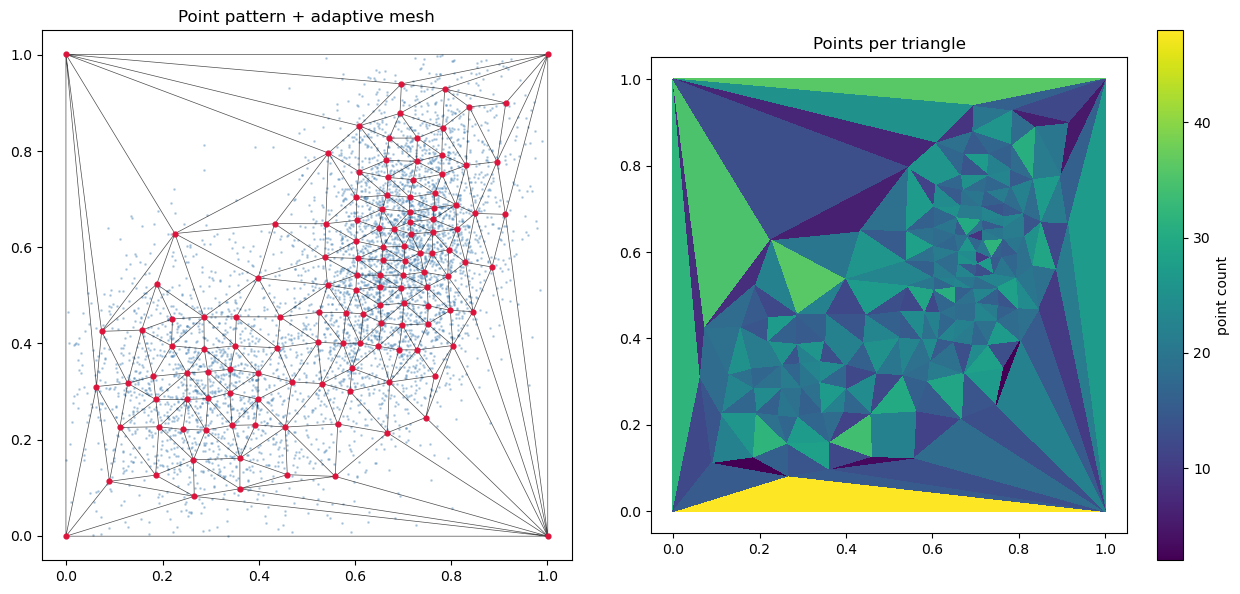

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

tri = mesh.triangulation

# Left: scatter + mesh
axes[0].scatter(points[:, 0], points[:, 1], s=1, alpha=0.3, color="steelblue")
axes[0].triplot(tri.points[:, 0], tri.points[:, 1], tri.simplices, color="k", lw=0.5, alpha=0.7)
axes[0].scatter(mesh.nodes[:, 0], mesh.nodes[:, 1], s=12, color="crimson", zorder=3)
axes[0].set_aspect("equal")
axes[0].set_title("Point pattern + adaptive mesh")

# Right: per-triangle count as a heatmap
counts = mesh.triangle_counts()
tpc = axes[1].tripcolor(
    tri.points[:, 0], tri.points[:, 1], tri.simplices,
    facecolors=counts, cmap="viridis"
)
plt.colorbar(tpc, ax=axes[1], label="point count")
axes[1].set_aspect("equal")
axes[1].set_title("Points per triangle")

plt.tight_layout()
plt.show()

## SPDE prior using Lindgren, Rue and Lindstroem (LRL) method

In [4]:
import numpy as np
import scipy.linalg as la
from triangulation import assemble_fem_matrices, precision_matrix

kappa = 6.0   # inverse range: larger -> shorter correlation length
alpha = 2     # smoothness order: nu = alpha - d/2 = 1 for d=2

C, G = assemble_fem_matrices(mesh.nodes, mesh.triangulation.simplices)
K, Q = precision_matrix(C, G, kappa=kappa, alpha=alpha)

Q_dense = Q.toarray()
Q_dense += 1e-10 * np.eye(len(Q_dense))  # jitter for numerical safety
L = la.cholesky(Q_dense, lower=True)      # Q = L L^T

def sample_prior(n_samples=1, seed=None):
    """Draw n_samples from N(0, Q^{-1}) by solving L^T x = z, z ~ N(0,I)."""
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((len(L), n_samples))
    return la.solve_triangular(L.T, z, lower=False)  # shape (n_nodes, n_samples)

samples = sample_prior(n_samples=4, seed=0)
print(f"Sample shape: {samples.shape}")
print(f"Sample std (should be ~1 for white noise prior): {samples.std(axis=0).round(3)}")

Sample shape: (132, 4)
Sample std (should be ~1 for white noise prior): [0.035 0.04  0.061 0.038]


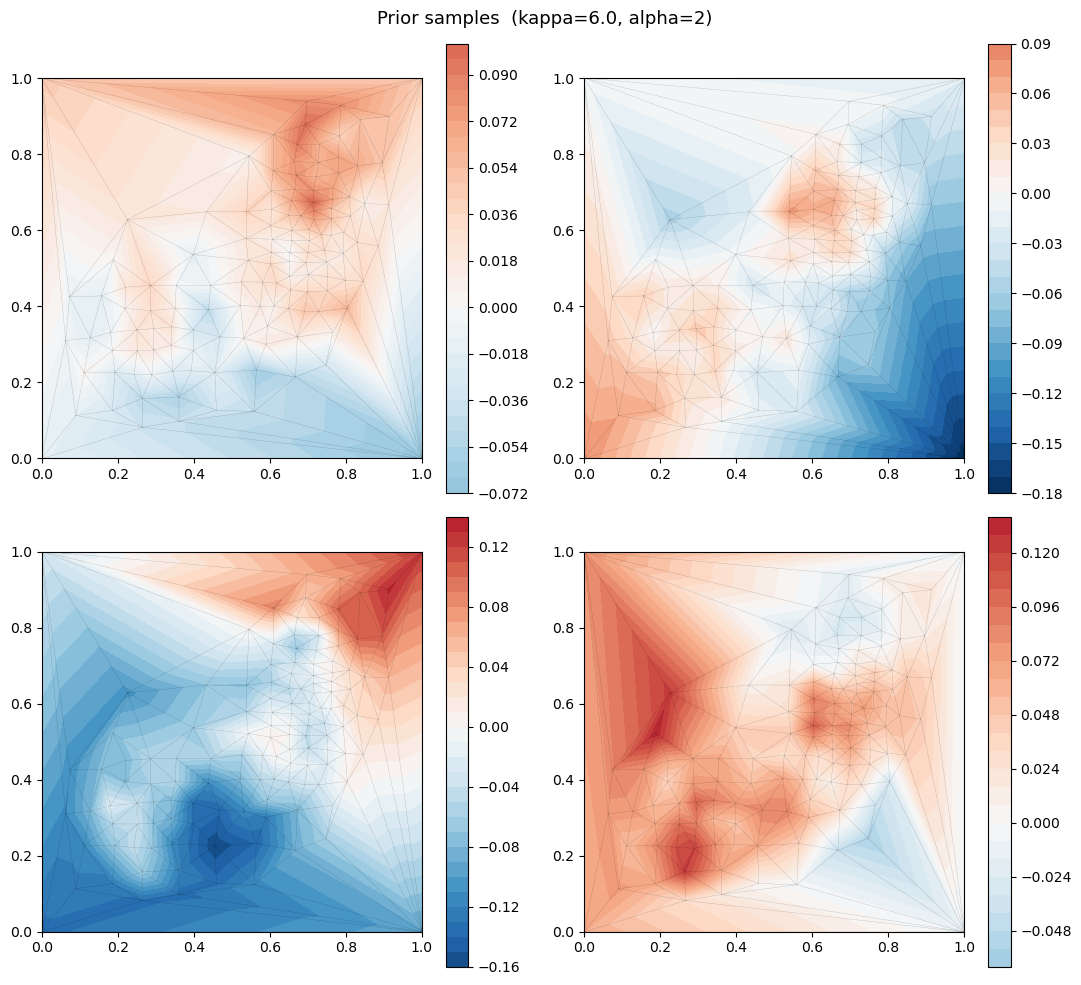

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
nodes = mesh.nodes
simplices = mesh.triangulation.simplices

vmax = np.abs(samples).max()

for ax, s in zip(axes.ravel(), samples.T):
    tcf = ax.tricontourf(
        nodes[:, 0], nodes[:, 1], simplices, s,
        levels=30, cmap="RdBu_r", vmin=-vmax, vmax=vmax
    )
    ax.triplot(nodes[:, 0], nodes[:, 1], simplices, color="k", lw=0.2, alpha=0.3)
    ax.set(xlim=(0,1), ylim=(0,1), aspect="equal")
    plt.colorbar(tcf, ax=ax)

fig.suptitle(f"Prior samples  (kappa={kappa}, alpha={alpha})", fontsize=13)
plt.tight_layout()
plt.show()

## Posterior inference via NUTS (BlackJAX)

In [6]:
from inference import make_log_posterior, run_nuts, predict_intensity

log_post, meta = make_log_posterior(
    Q, mesh.nodes, mesh.triangulation.simplices, mesh.triangulation, points,
)

samples, info = run_nuts(
    log_post, meta,
    n_nodes             = len(mesh.nodes),
    num_warmup          = 1000,
    num_samples         = 1000,
    thinning            = 10,
    seed                = 0,
    progress_bar_kwargs = {"tqdm_type": "std", "print_rate": 10},
)

c = meta["c_lumped"]
N_samples = (np.exp(np.array(samples["x"]) + np.array(samples["mu"])[:, None]) * c).sum(axis=1)
print(f"E[N_obs] = {N_samples.mean():.1f}  (should equal n_obs = {meta['n_obs']})")
print(f"domain_area = {meta['domain_area']:.4f}  (full mesh including buffer)")


Running 1000 warmup steps...
  step_size = 0.0849


Sampling: 100%|██████████| 1000/1000 [00:13<00:00, 74.34it/s]


  acceptance rate = 0.83,  divergences = 0
E[N_obs] = 5002.9  (should equal n_obs = 5002)
domain_area = 1.0040  (full mesh including buffer)


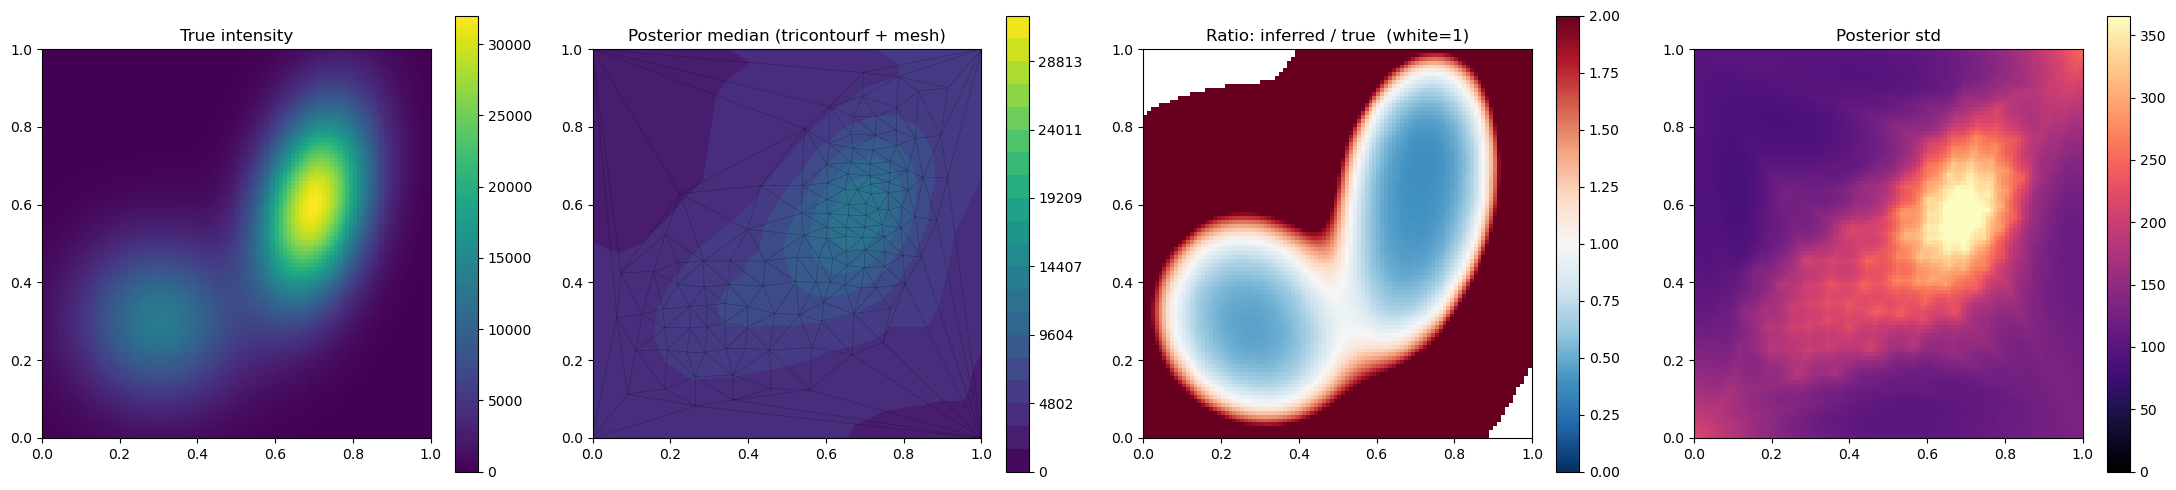

In [7]:
import numpy as np
from matplotlib.tri import Triangulation as MplTri

grid_1d = np.linspace(0, 1, 100)
gx, gy  = np.meshgrid(grid_1d, grid_1d)
grid    = np.column_stack([gx.ravel(), gy.ravel()])

lam           = predict_intensity(samples, mesh.nodes, mesh.triangulation, grid)
median_lam    = np.median(lam, axis=0)
std_lam       = np.std(lam, axis=0)
median_lam_2d = median_lam.reshape(100, 100)
std_lam_2d    = std_lam.reshape(100, 100)

true_lam    = mixture_density(grid, components) * meta["n_obs"]
true_lam_2d = true_lam.reshape(100, 100)

mu_med    = float(np.median(np.array(samples["mu"])))
x_med     = np.median(np.array(samples["x"]), axis=0)
lam_nodes = np.exp(mu_med + x_med)
mpl_tri   = MplTri(mesh.nodes[:, 0], mesh.nodes[:, 1], mesh.triangulation.simplices)

vmax     = true_lam_2d.max()
vmax_std = float(np.percentile(std_lam_2d, 99))
kw_im    = dict(origin="lower", extent=[0, 1, 0, 1], aspect="equal")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

im0 = axes[0].imshow(true_lam_2d, cmap="viridis", vmin=0, vmax=vmax, **kw_im)
axes[0].set_title("True intensity")
plt.colorbar(im0, ax=axes[0])

levels = np.linspace(0, vmax, 21)
tcf = axes[1].tricontourf(mpl_tri, lam_nodes, levels=levels, cmap="viridis")
axes[1].triplot(mpl_tri, color="k", lw=0.3, alpha=0.4)
axes[1].set(xlim=(0, 1), ylim=(0, 1), aspect="equal",
            title="Posterior median (tricontourf + mesh)")
plt.colorbar(tcf, ax=axes[1])

safe_true = np.where(true_lam_2d > 1.0, true_lam_2d, np.nan)
ratio     = median_lam_2d / safe_true
im2 = axes[2].imshow(ratio, cmap="RdBu_r", vmin=0, vmax=2, **kw_im)
axes[2].set_title("Ratio: inferred / true  (white=1)")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(std_lam_2d, cmap="magma", vmin=0, vmax=vmax_std, **kw_im)
axes[3].set_title("Posterior std")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()


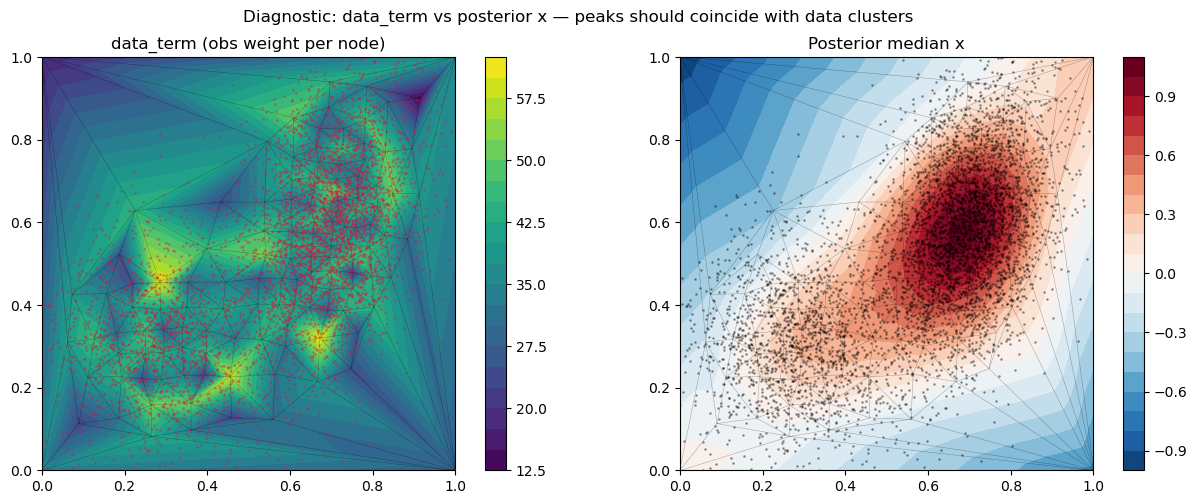

Top-5 nodes by data_term  (should be near cluster centres):
  node  69  pos=(0.672, 0.319)  data_term=60.999
  node  41  pos=(0.286, 0.455)  data_term=60.167
  node  26  pos=(0.455, 0.226)  data_term=57.406
  node 106  pos=(0.714, 0.674)  data_term=51.797
  node  56  pos=(0.543, 0.521)  data_term=51.433
Top-5 nodes by posterior x_med:
  node  90  pos=(0.704, 0.572)  x_med=1.032
  node  91  pos=(0.703, 0.602)  x_med=1.026
  node  88  pos=(0.658, 0.573)  x_med=1.021
  node  87  pos=(0.700, 0.542)  x_med=1.013
  node  85  pos=(0.653, 0.542)  x_med=1.012


In [8]:
# Vertex-correspondence diagnostic.
# If node indices are correct, data_term and posterior x_med should both peak
# near the data cluster locations.  Any "rotation" artifact would show up as
# the two plots having their hot-spots at different mesh nodes.
x_med_diag  = np.median(np.array(samples["x"]), axis=0)   # (n_nodes,)
data_term_d = meta["data_term"]                             # (n_nodes,)

mpl_tri_d = MplTri(mesh.nodes[:, 0], mesh.nodes[:, 1], mesh.triangulation.simplices)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tcf0 = axes[0].tricontourf(mpl_tri_d, data_term_d, levels=20, cmap="viridis")
axes[0].triplot(mpl_tri_d, color="k", lw=0.3, alpha=0.4)
axes[0].scatter(points[:, 0], points[:, 1], s=1, color="crimson", alpha=0.3)
axes[0].set(xlim=(0, 1), ylim=(0, 1), aspect="equal", title="data_term (obs weight per node)")
plt.colorbar(tcf0, ax=axes[0])

vmax_x = np.abs(x_med_diag).max()
tcf1 = axes[1].tricontourf(mpl_tri_d, x_med_diag, levels=20, cmap="RdBu_r",
                            vmin=-vmax_x, vmax=vmax_x)
axes[1].triplot(mpl_tri_d, color="k", lw=0.3, alpha=0.4)
axes[1].scatter(points[:, 0], points[:, 1], s=1, color="k", alpha=0.3)
axes[1].set(xlim=(0, 1), ylim=(0, 1), aspect="equal", title="Posterior median x")
plt.colorbar(tcf1, ax=axes[1])

plt.suptitle("Diagnostic: data_term vs posterior x — peaks should coincide with data clusters")
plt.tight_layout()
plt.show()

top5_dt = np.argsort(data_term_d)[-5:][::-1]
top5_x  = np.argsort(x_med_diag)[-5:][::-1]
print("Top-5 nodes by data_term  (should be near cluster centres):")
for i in top5_dt:
    print(f"  node {i:3d}  pos=({mesh.nodes[i,0]:.3f}, {mesh.nodes[i,1]:.3f})  data_term={data_term_d[i]:.3f}")
print("Top-5 nodes by posterior x_med:")
for i in top5_x:
    print(f"  node {i:3d}  pos=({mesh.nodes[i,0]:.3f}, {mesh.nodes[i,1]:.3f})  x_med={x_med_diag[i]:.3f}")

In [9]:
# Barycentric convention diagnostic.
#
# (1) Verify scipy transform convention: transform[i, d, :] is the LAST simplex
#     vertex (simplices[i, d]), NOT the first.  The "residual" coordinate
#     bary_0 = 1 - c.sum() therefore corresponds to simplices[idx, d],
#     so the correct order is bary = [bary_rest, bary_0], not [bary_0, bary_rest].
#
# (2) Verify predict_intensity at exact node positions recovers exp(mu + x).
#     Any permutation bug shows up as a non-zero error here.

tri_c    = mesh.triangulation
i_c      = 0
v_first  = mesh.nodes[tri_c.simplices[i_c,  0]]
v_last   = mesh.nodes[tri_c.simplices[i_c, -1]]
ref_pt   = tri_c.transform[i_c, 2, :]           # transform[i, d, :]

print("=== scipy transform[i, d, :] convention ===")
print(f"simplices[0] = {tri_c.simplices[i_c]}")
print(f"transform[0, d, :] = {ref_pt}")
print(f"first vertex pos   = {v_first}  → match: {np.allclose(ref_pt, v_first)}")
print(f"last  vertex pos   = {v_last}   → match: {np.allclose(ref_pt, v_last)}")

print()
print("=== predict_intensity at node positions (should be zero error) ===")
s0          = 0
mu_s0       = float(np.array(samples["mu"])[s0])
x_s0        = np.array(samples["x"])[s0]
single_samp = {k: np.array(v)[s0:s0+1] for k, v in samples.items()}
lam_at_nod  = predict_intensity(single_samp, mesh.nodes, tri_c, mesh.nodes)[0]
expected    = np.exp(mu_s0 + x_s0)
print(f"Max absolute error: {np.abs(lam_at_nod - expected).max():.3e}")
print(f"Max relative error: {(np.abs(lam_at_nod - expected)/(expected+1e-10)).max():.3e}")
print("(Should be < 1e-10 if bary ordering is correct)")

=== scipy transform[i, d, :] convention ===
simplices[0] = [12  1  0]
transform[0, d, :] = [-0.001 -0.001]
first vertex pos   = [0.06251642 0.31015789]  → match: False
last  vertex pos   = [-0.001 -0.001]   → match: True

=== predict_intensity at node positions (should be zero error) ===
Max absolute error: 0.000e+00
Max relative error: 0.000e+00
(Should be < 1e-10 if bary ordering is correct)


## Joint inference of field + kappa hyperparameter

Isotropic and stationary kernel (basically PixelPop), but seems to do well

In [10]:
from inference import make_log_posterior_with_hyperparams, run_nuts, predict_intensity

log_post_hyper, meta_hyper = make_log_posterior_with_hyperparams(
    C, G,
    mesh.nodes, mesh.triangulation.simplices, mesh.triangulation,
    points,
    alpha         = 2,
    log_kappa_std = 1.0,
)

samples_hyper, info_hyper = run_nuts(
    log_post_hyper, meta_hyper,
    n_nodes     = len(mesh.nodes),
    num_warmup  = 1000,
    num_samples = 1000,
    seed        = 0,
    thinning    = 10,
    progress_bar_kwargs = {"tqdm_type": "std", "print_rate": 10},
)

c = meta_hyper["c_lumped"]
N_samples = (np.exp(np.array(samples_hyper["x"]) + np.array(samples_hyper["mu"])[:, None]) * c).sum(axis=1)
print(f"E[N_obs] = {N_samples.mean():.1f}  (should equal n_obs = {meta_hyper['n_obs']})")


Running 1000 warmup steps...
  step_size = 0.0410


Sampling: 100%|██████████| 1000/1000 [00:07<00:00, 142.16it/s]

  acceptance rate = 0.92,  divergences = 0
E[N_obs] = 5002.4  (should equal n_obs = 5002)


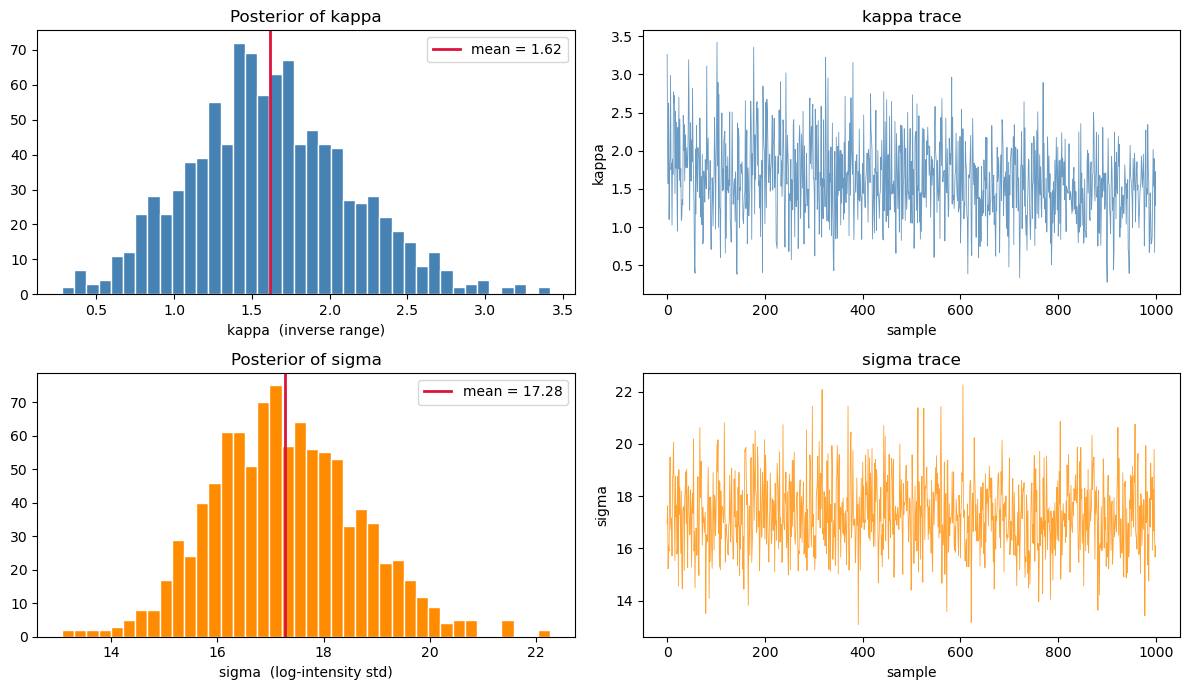

kappa  mean=1.617  std=0.524
sigma  mean=17.280  std=1.390
mu     mean=13.912  std=1.047
accept rate = 0.92,  divergences = 0


In [11]:
import numpy as np

kappas = np.exp(np.array(samples_hyper["log_kappa"]))
sigmas = np.exp(np.array(samples_hyper["log_sigma"]))
mus    = np.array(samples_hyper["mu"])

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].hist(kappas, bins=40, color="steelblue", edgecolor="white")
axes[0, 0].axvline(kappas.mean(), color="crimson", lw=2, label=f"mean = {kappas.mean():.2f}")
axes[0, 0].set(xlabel="kappa  (inverse range)", title="Posterior of kappa")
axes[0, 0].legend()

axes[0, 1].plot(kappas, color="steelblue", lw=0.6, alpha=0.8)
axes[0, 1].set(xlabel="sample", ylabel="kappa", title="kappa trace")

axes[1, 0].hist(sigmas, bins=40, color="darkorange", edgecolor="white")
axes[1, 0].axvline(sigmas.mean(), color="crimson", lw=2, label=f"mean = {sigmas.mean():.2f}")
axes[1, 0].set(xlabel="sigma  (log-intensity std)", title="Posterior of sigma")
axes[1, 0].legend()

axes[1, 1].plot(sigmas, color="darkorange", lw=0.6, alpha=0.8)
axes[1, 1].set(xlabel="sample", ylabel="sigma", title="sigma trace")

plt.tight_layout()
plt.show()

print(f"kappa  mean={kappas.mean():.3f}  std={kappas.std():.3f}")
print(f"sigma  mean={sigmas.mean():.3f}  std={sigmas.std():.3f}")
print(f"mu     mean={mus.mean():.3f}  std={mus.std():.3f}")
print(f"accept rate = {float(info_hyper.acceptance_rate.mean()):.2f},  divergences = {int(info_hyper.is_divergent.sum())}")


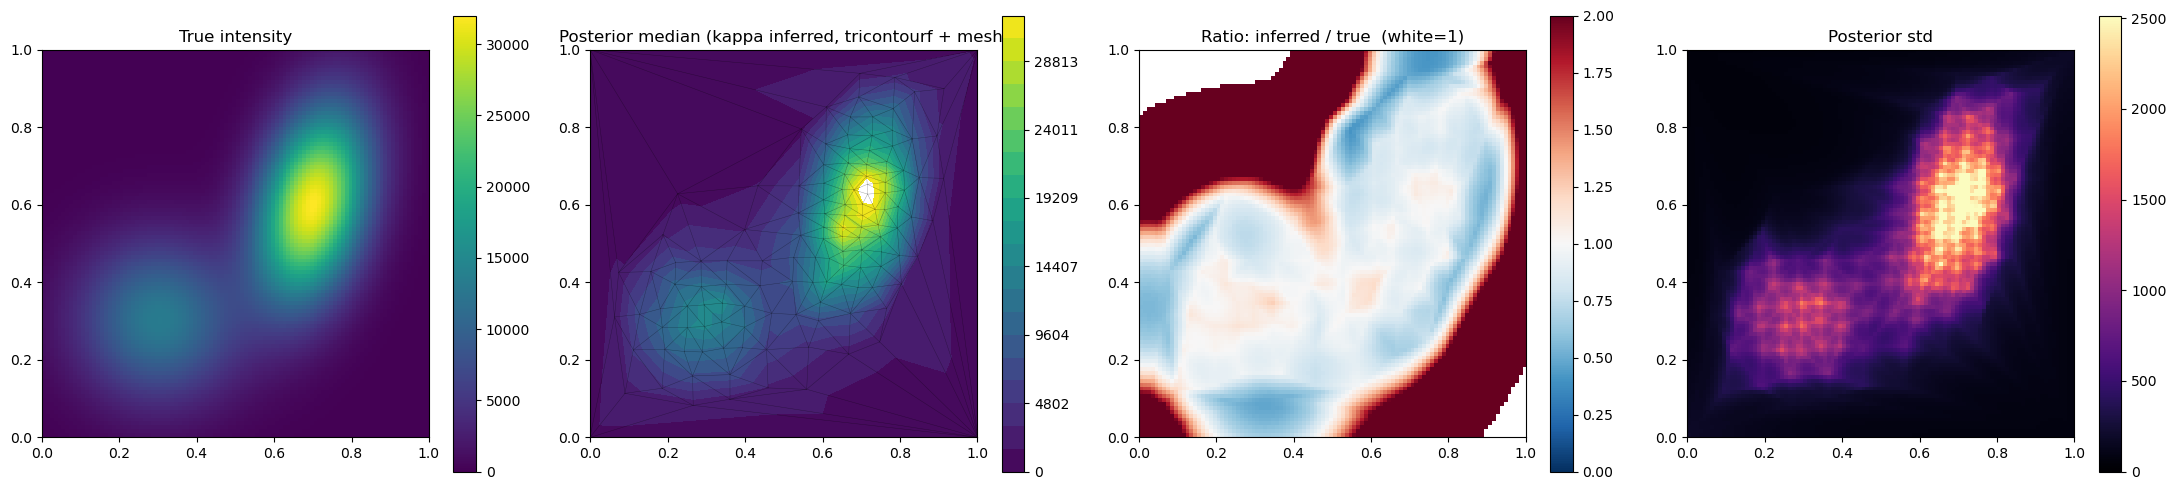

In [12]:
grid_1d = np.linspace(0, 1, 100)
gx, gy  = np.meshgrid(grid_1d, grid_1d)
grid    = np.column_stack([gx.ravel(), gy.ravel()])

lam_h           = predict_intensity(samples_hyper, mesh.nodes, mesh.triangulation, grid)
median_lam_h    = np.median(lam_h, axis=0)
std_lam_h       = np.std(lam_h, axis=0)
median_lam_2d_h = median_lam_h.reshape(100, 100)
std_lam_2d_h    = std_lam_h.reshape(100, 100)
true_lam_2d     = (mixture_density(grid, components) * meta_hyper["n_obs"]).reshape(100, 100)

mu_med_h    = float(np.median(np.array(samples_hyper["mu"])))
x_med_h     = np.median(np.array(samples_hyper["x"]), axis=0)
lam_nodes_h = np.exp(mu_med_h + x_med_h)
mpl_tri     = MplTri(mesh.nodes[:, 0], mesh.nodes[:, 1], mesh.triangulation.simplices)

vmax     = true_lam_2d.max()
vmax_std = float(np.percentile(std_lam_2d_h, 99))
kw_im    = dict(origin="lower", extent=[0, 1, 0, 1], aspect="equal")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

im0 = axes[0].imshow(true_lam_2d, cmap="viridis", vmin=0, vmax=vmax, **kw_im)
axes[0].set_title("True intensity")
plt.colorbar(im0, ax=axes[0])

levels = np.linspace(0, vmax, 21)
tcf = axes[1].tricontourf(mpl_tri, lam_nodes_h, levels=levels, cmap="viridis")
axes[1].triplot(mpl_tri, color="k", lw=0.3, alpha=0.4)
axes[1].set(xlim=(0, 1), ylim=(0, 1), aspect="equal",
            title="Posterior median (kappa inferred, tricontourf + mesh)")
plt.colorbar(tcf, ax=axes[1])

safe_true = np.where(true_lam_2d > 1.0, true_lam_2d, np.nan)
ratio_h   = median_lam_2d_h / safe_true
im2 = axes[2].imshow(ratio_h, cmap="RdBu_r", vmin=0, vmax=2, **kw_im)
axes[2].set_title("Ratio: inferred / true  (white=1)")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(std_lam_2d_h, cmap="magma", vmin=0, vmax=vmax_std, **kw_im)
axes[3].set_title("Posterior std")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()


## Anisotropic kernel, stationary still